<a href="https://colab.research.google.com/github/kbundaleski9000/msc_project_trading/blob/test/NahConv_Deep_CFR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[equilibrium] computed sequences for T=5 (scipy=True)
[device] cpu
[eval] it=   200 | MAE(beta)=0.0689 | MAE(lambda)=0.0419 | NashConv=2.9437 | buffers: advI=200000, advM=200000, polI=200000, polM=200000
[eval] it=   400 | MAE(beta)=0.1351 | MAE(lambda)=0.0371 | NashConv=3.5925 | buffers: advI=200000, advM=200000, polI=200000, polM=200000
[eval] it=   600 | MAE(beta)=0.3148 | MAE(lambda)=0.0346 | NashConv=2.8959 | buffers: advI=200000, advM=200000, polI=200000, polM=200000
[eval] it=   800 | MAE(beta)=0.1980 | MAE(lambda)=0.0535 | NashConv=3.3451 | buffers: advI=200000, advM=200000, polI=200000, polM=200000
[eval] it=  1000 | MAE(beta)=0.2590 | MAE(lambda)=0.0391 | NashConv=2.6839 | buffers: advI=200000, advM=200000, polI=200000, polM=200000
[eval] it=  1200 | MAE(beta)=0.2939 | MAE(lambda)=0.1082 | NashConv=3.4143 | buffers: advI=200000, advM=200000, polI=200000, polM=200000
[eval] it=  1400 | MAE(beta)=0.2530 | MAE(lambda)=0.0540 | NashConv=2.9715 | buffers: advI=200000, advM=200000,

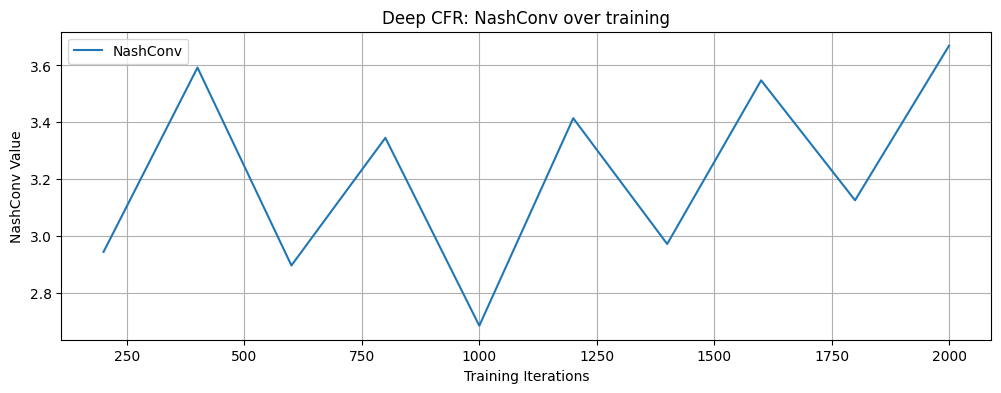

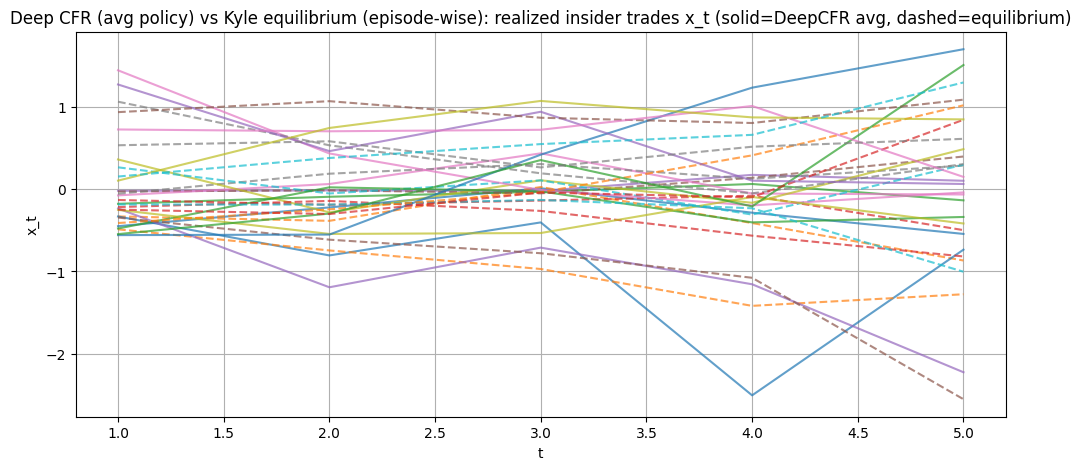

/tmp/ipython-input-1378636947.py:912: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


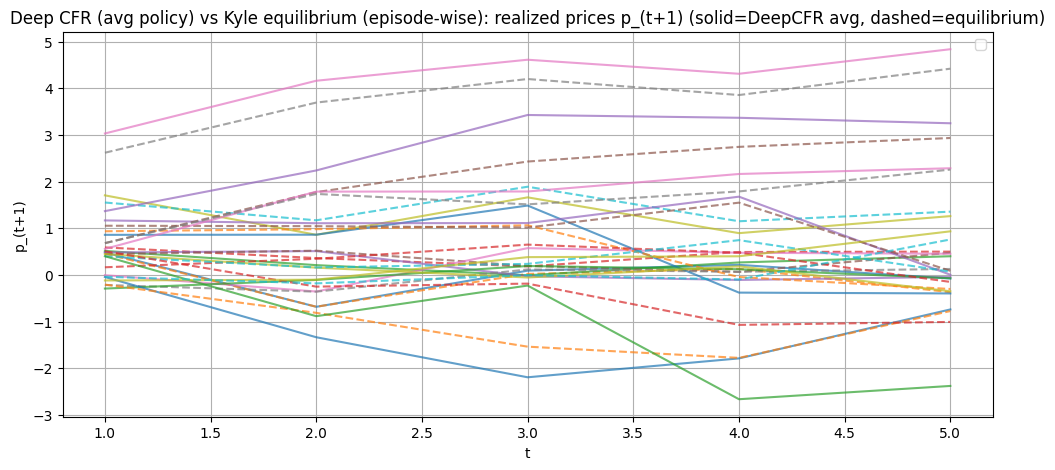

Sampled true v per episode:
  ep 00: v = -0.6216
  ep 01: v =  0.0588
  ep 02: v =  0.4093
  ep 03: v =  0.3155
  ep 04: v =  1.4077
  ep 05: v = -1.1540
  ep 06: v = -0.2340
  ep 07: v = -0.6679
  ep 08: v =  4.1196
  ep 09: v = -0.1261
  ep 10: v = -0.8936
  ep 11: v = -0.3391
  ep 12: v =  3.6884
  ep 13: v =  2.3200
  ep 14: v =  1.0277
All done.


In [ ]:
import os
import math
import random
from dataclasses import dataclass
from typing import Dict, Tuple, Any, Optional, List

import numpy as np
import matplotlib.pyplot as plt

# --- PyTorch (Deep CFR)
import torch
import torch.nn as nn
import torch.optim as optim


# ============================================================
# Utilities (same spirit as your code)
# ============================================================

def safe_normalize(x: np.ndarray) -> np.ndarray:
    s = float(x.sum())
    if s > 1e-15:
        return x / s
    return np.ones_like(x) / len(x)

def regret_matching_from_advantages(adv: np.ndarray) -> np.ndarray:
    """Regret-matching using positive advantages."""
    r_pos = np.maximum(adv, 0.0)
    s = float(r_pos.sum())
    if s > 1e-15:
        return r_pos / s
    return np.ones_like(r_pos) / len(r_pos)

def set_global_seeds(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# ============================================================
# Multi-period Kyle equilibrium solver (your algorithm)
# (kept as-is except SciPy fallback removed for brevity;
#  if you want, paste your original solve_kyle_model here.)
# ============================================================

# Optional: if SciPy is available we use brentq; otherwise bisection
try:
    from scipy.optimize import brentq  # type: ignore
    _HAVE_SCIPY = True
except Exception:
    brentq = None
    _HAVE_SCIPY = False

def bisect_root(f, a: float, b: float, tol: float = 1e-10, max_iter: int = 200) -> float:
    fa = f(a)
    fb = f(b)
    if not np.isfinite(fa) or not np.isfinite(fb) or fa * fb > 0:
        raise ValueError("Bisection requires bracket with opposite signs.")
    lo, hi = a, b
    flo, fhi = fa, fb
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        fmid = f(mid)
        if abs(fmid) < tol or (hi - lo) < tol:
            return mid
        if flo * fmid <= 0:
            hi, fhi = mid, fmid
        else:
            lo, flo = mid, fmid
    return 0.5 * (lo + hi)

def solve_kyle_model(N: int, sigma2_v: float, sigma2_u: float):
    sigma_u = float(np.sqrt(sigma2_u))

    # PASS 1: backward for h
    h = np.zeros(N, dtype=float)
    h[-1] = 0.5
    for n in reversed(range(N - 1)):
        h_next = float(h[n + 1])
        theta_next = float(np.sqrt(h_next / (1.0 - h_next)))

        def root_func(h_n: float) -> float:
            if (h_n <= 0.5) or (h_n >= 1.0):
                return np.inf
            return theta_next - (2.0 * h_n - 1.0) / (h_n * np.sqrt(1.0 - h_n))

        lo = 0.5 + 1e-9
        hi = 1.0 - 1e-9
        if _HAVE_SCIPY:
            h[n] = float(brentq(root_func, lo, hi))
        else:
            xs = np.linspace(lo, hi, 2000)
            vals = np.array([root_func(x) for x in xs], dtype=float)
            ok = np.isfinite(vals)
            xs, vals = xs[ok], vals[ok]
            idx = None
            for k in range(len(vals) - 1):
                if vals[k] == 0.0 or vals[k] * vals[k + 1] < 0:
                    idx = k
                    break
            if idx is None:
                raise RuntimeError("Could not bracket root for h_n without SciPy.")
            h[n] = float(bisect_root(root_func, float(xs[idx]), float(xs[idx + 1])))

    # PASS 2: forward sequences
    Sigma = np.zeros(N + 1, dtype=float)
    Lambda = np.zeros(N, dtype=float)
    Beta = np.zeros(N, dtype=float)
    Alpha = np.zeros(N, dtype=float)

    Sigma[0] = float(sigma2_v)
    for n in range(N):
        Sigma[n + 1] = float(h[n] * Sigma[n])
        Lambda[n] = float(np.sqrt((1.0 - h[n]) * Sigma[n + 1]) / sigma_u)
        Beta[n] = float((np.sqrt(1.0 - h[n]) * sigma_u) / np.sqrt(Sigma[n + 1]))
        Alpha[n] = float((sigma_u / (2.0 * np.sqrt(Sigma[n]))) * np.sqrt(h[n] / (1.0 - h[n])))

    return {"Sigma": Sigma, "Lambda": Lambda, "Beta": Beta, "Alpha": Alpha, "h": h}


# ============================================================
# Kyle dynamics (kept from your code)
# ============================================================

def bayes_update_sigma(Sigma_prev: float, beta: float, sigma_u: float) -> float:
    denom = beta**2 * Sigma_prev + sigma_u**2
    if denom < 1e-15:
        return Sigma_prev
    return Sigma_prev * sigma_u**2 / denom

def kyle_step_beta_lambda(beta: float, lam: float, v: float, p_prev: float, u: float):
    x = beta * (v - p_prev)
    y = x + u
    p_next = p_prev + lam * y
    u_ins = x * (v - p_next)
    u_mm = -(p_next - v) ** 2
    return x, y, p_next, u_ins, u_mm


# ============================================================
# Deep CFR components
# ============================================================

@dataclass
class DeepCFRConfig:
    T: int = 5
    P0: float = 0.5
    sigma_v: float = math.sqrt(2.0)
    sigma_u: float = 1.0
    insider_actions: Tuple[float, ...] = (0.20, 0.40, 0.65, 0.95, 1.35, 1.90)  # β grid
    mm_actions: Tuple[float, ...] = (0.10, 0.20, 0.35, 0.55, 0.85, 1.25)       # λ grid
    include_p_in_mm_infoset: bool = False

    # Deep CFR training
    num_iterations: int = 5000
    eval_every: int = 300
    eval_simulations: int = 200
    eval_seed: int = 123

    # Advantage learning
    adv_hidden: int = 128
    adv_lr: float = 1e-3
    adv_train_steps: int = 20     # MODIFIED: Reduced from 100 to 20
    adv_batch_size: int = 256

    # Avg strategy learning
    pol_hidden: int = 128
    pol_lr: float = 1e-3
    pol_train_steps: int = 20     # MODIFIED: Reduced from 100 to 20
    pol_batch_size: int = 256

    # Replay buffers
    adv_buffer_max: int = 200_000
    pol_buffer_max: int = 200_000

    # Variance reduction (cost ↑)
    num_action_rollouts: int = 1  # K rollouts per action when computing advantages


class ReplayBuffer:
    def __init__(self, max_size: int):
        self.max_size = int(max_size)
        self.data: List[Tuple[np.ndarray, np.ndarray]] = []

    def add(self, x: np.ndarray, y: np.ndarray):
        if len(self.data) >= self.max_size:
            # FIFO
            self.data.pop(0)
        self.data.append((x.astype(np.float32), y.astype(np.float32)))

    def sample(self, batch_size: int):
        batch = random.sample(self.data, k=min(batch_size, len(self.data)))
        xs = np.stack([b[0] for b in batch], axis=0)
        ys = np.stack([b[1] for b in batch], axis=0)
        return xs, ys

    def __len__(self):
        return len(self.data)


class MLP(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# ============================================================
# State feature encoding (Deep CFR: continuous features)
# ============================================================

def insider_features(v: float, p: float, Sigma: float, t: int, T: int) -> np.ndarray:
    # Features: [v, p, Sigma, t/T, 1]
    return np.array([v, p, Sigma, float(t) / float(T), 1.0], dtype=np.float32)

def mm_features(y: float, Sigma: float, t: int, T: int, p: Optional[float] = None) -> np.ndarray:
    # If you include p in mm infoset, add it; otherwise omit.
    if p is None:
        return np.array([y, Sigma, float(t) / float(T), 1.0], dtype=np.float32)
    return np.array([y, p, Sigma, float(t) / float(T), 1.0], dtype=np.float32)


# ============================================================
# Deep CFR Trainer (External Sampling)
# ============================================================

class DeepCFRKyle:
    def __init__(self, cfg: DeepCFRConfig, device: Optional[str] = None, seed: int = 0):
        self.cfg = cfg
        set_global_seeds(seed)

        self.device = torch.device(device if device is not None else ("cuda" if torch.cuda.is_available() else "cpu"))

        self.T = cfg.T
        self.P0 = cfg.P0
        self.sigma_v = cfg.sigma_v
        self.sigma_u = cfg.sigma_u
        self.include_p_in_mm = cfg.include_p_in_mm_infoset

        self.INSIDER_ACTIONS = np.array(cfg.insider_actions, dtype=np.float32)
        self.MM_ACTIONS = np.array(cfg.mm_actions, dtype=np.float32)

        # Feature dims
        self.ins_dim = 5
        self.mm_dim = 4 if not self.include_p_in_mm else 5

        # Advantage nets: output advantages per action
        self.adv_I = MLP(self.ins_dim, len(self.INSIDER_ACTIONS), hidden=cfg.adv_hidden).to(self.device)
        self.adv_M = MLP(self.mm_dim, len(self.MM_ACTIONS), hidden=cfg.adv_hidden).to(self.device)

        # Average policy nets: output logits per action
        self.pol_I = MLP(self.ins_dim, len(self.INSIDER_ACTIONS), hidden=cfg.pol_hidden).to(self.device)
        self.pol_M = MLP(self.mm_dim, len(self.MM_ACTIONS), hidden=cfg.pol_hidden).to(self.device)

        self.opt_adv_I = optim.Adam(self.adv_I.parameters(), lr=cfg.adv_lr)
        self.opt_adv_M = optim.Adam(self.adv_M.parameters(), lr=cfg.adv_lr)
        self.opt_pol_I = optim.Adam(self.pol_I.parameters(), lr=cfg.pol_lr)
        self.opt_pol_M = optim.Adam(self.pol_M.parameters(), lr=cfg.pol_lr)

        self.adv_buf_I = ReplayBuffer(cfg.adv_buffer_max)
        self.adv_buf_M = ReplayBuffer(cfg.adv_buffer_max)
        self.pol_buf_I = ReplayBuffer(cfg.pol_buffer_max)
        self.pol_buf_M = ReplayBuffer(cfg.pol_buffer_max)

        self.rng = np.random.default_rng(seed)

    @torch.no_grad()
    def _policy_from_adv(self, player: str, feats: np.ndarray) -> np.ndarray:
        """Current behavior policy via regret-matching on predicted advantages."""
        x = torch.tensor(feats[None, :], dtype=torch.float32, device=self.device)
        if player == "I":
            adv = self.adv_I(x).cpu().numpy()[0]
        else:
            adv = self.adv_M(x).cpu().numpy()[0]
        pi = regret_matching_from_advantages(adv)
        return pi.astype(np.float32)

    @torch.no_grad()
    def _avg_policy(self, player: str, feats: np.ndarray) -> np.ndarray:
        """Average strategy (Deep CFR) from policy net."""
        x = torch.tensor(feats[None, :], dtype=torch.float32, device=self.device)
        if player == "I":
            logits = self.pol_I(x).cpu().numpy()[0]
        else:
            logits = self.pol_M(x).cpu().numpy()[0]
        # stable softmax
        m = np.max(logits)
        probs = np.exp(logits - m)
        probs = safe_normalize(probs)
        return probs.astype(np.float32)

    def _sample_action(self, probs: np.ndarray) -> int:
        return int(self.rng.choice(len(probs), p=probs))

    def _mm_feat(self, y: float, Sigma: float, t: int, p: float) -> np.ndarray:
        if self.include_p_in_mm:
            return mm_features(y, Sigma, t, self.T, p=p)
        return mm_features(y, Sigma, t, self.T, p=None)

    def _get_action_from_policy(self, player: str, feats: np.ndarray) -> int:
        """Returns a sampled action index from the player's current average policy."""
        avg_policy_probs = self._avg_policy(player, feats)
        sampled_action_index = self._sample_action(avg_policy_probs)
        return sampled_action_index

    def _rollout_from_state(self, t: int, p: float, Sigma: float, v: float, u_seq: np.ndarray) -> Tuple[float, float]:
        """Simulates the game from a given state to the end using average policies."""
        if t == self.T:
            return 0.0, 0.0

        u_t = float(u_seq[t])

        # Insider's turn: sample action from average policy
        ins_f = insider_features(v, p, Sigma, t, self.T)
        i = self._get_action_from_policy("I", ins_f)
        beta_t = float(self.INSIDER_ACTIONS[i])

        # Intermediate values before MM action
        x_t = beta_t * (v - p)
        y_t = x_t + u_t

        # Market Maker's turn: sample action from average policy
        mm_f = self._mm_feat(y_t, Sigma, t, p)
        j = self._get_action_from_policy("M", mm_f)
        lam_t = float(self.MM_ACTIONS[j])

        # Apply chosen actions and get utilities for current step
        _, _, p_next, u_ins_t, u_mm_t = kyle_step_beta_lambda(beta_t, lam_t, v, p, u_t)
        Sigma_next = bayes_update_sigma(Sigma, beta_t, self.sigma_u)

        # Recursively get continuation utilities
        cont_ins, cont_mm = self._rollout_from_state(t + 1, p_next, Sigma_next, v, u_seq)

        return u_ins_t + cont_ins, u_mm_t + cont_mm

    def _traverse_external_sampling(
        self,
        t: int,
        p: float,
        Sigma: float,
        v: float,
        u_seq: np.ndarray,
        player_to_update: str,
    ) -> Tuple[float, float]:
        """
        External sampling traversal.
        Returns continuation values (insider, mm) from time t onward.
        At updating player's infosets: enumerate all own actions to compute advantage targets.
        At opponent infosets: sample one action from current behavior policy.
        """
        if t == self.T:
            return 0.0, 0.0

        u = float(u_seq[t])

        # ---------- Insider node ----------
        ins_f = insider_features(v, p, Sigma, t, self.T)
        pi_I = self._policy_from_adv("I", ins_f)

        if player_to_update == "I":
            # enumerate insider actions
            util_ins = np.zeros(len(self.INSIDER_ACTIONS), dtype=np.float32)
            util_mm  = np.zeros(len(self.INSIDER_ACTIONS), dtype=np.float32)

            # store current behavior policy in avg strategy buffer
            self.pol_buf_I.add(ins_f, pi_I)

            for i, beta in enumerate(self.INSIDER_ACTIONS):
                # To reduce variance: average K rollouts per action (default K=1)
                K = max(1, self.cfg.num_action_rollouts)
                acc_ins = 0.0
                acc_mm  = 0.0
                for _ in range(K):
                    beta_f = float(beta)
                    x, y, _, u_ins, u_mm = kyle_step_beta_lambda(beta_f, 0.0, v, p, u)  # lam not applied yet

                    # MM node (opponent) sampled from policy
                    mm_f = self._mm_feat(y, Sigma, t, p)
                    pi_M = self._policy_from_adv("M", mm_f)
                    j = self._sample_action(pi_M)
                    lam = float(self.MM_ACTIONS[j])

                    _, _, p_next, u_ins2, u_mm2 = kyle_step_beta_lambda(beta_f, lam, v, p, u)
                    Sigma_next = bayes_update_sigma(Sigma, beta_f, self.sigma_u)

                    cont_ins, cont_mm = self._traverse_external_sampling(
                        t + 1, p_next, Sigma_next, v, u_seq, player_to_update
                    )
                    acc_ins += (u_ins2 + cont_ins)
                    acc_mm  += (u_mm2  + cont_mm)

                util_ins[i] = acc_ins / K
                util_mm[i]  = acc_mm  / K

            V_ins = float(np.dot(pi_I, util_ins))
            V_mm  = float(np.dot(pi_I, util_mm))

            # Advantage targets for insider: A(a)=u(a)-V
            adv_targets = util_ins - V_ins
            self.adv_buf_I.add(ins_f, adv_targets)

            return V_ins, V_mm

        # opponent node: sample insider action
        i = self._sample_action(pi_I)
        beta = float(self.INSIDER_ACTIONS[i])
        x = beta * (v - p)
        y = x + u

        # ---------- Market maker node ----------
        mm_f = self._mm_feat(y, Sigma, t, p)
        pi_M = self._policy_from_adv("M", mm_f)

        if player_to_update == "M":
            # enumerate mm actions
            util_ins = np.zeros(len(self.MM_ACTIONS), dtype=np.float32)
            util_mm  = np.zeros(len(self.MM_ACTIONS), dtype=np.float32)

            # store current behavior policy in avg strategy buffer
            self.pol_buf_M.add(mm_f, pi_M)

            for j, lam in enumerate(self.MM_ACTIONS):
                K = max(1, self.cfg.num_action_rollouts)
                acc_ins = 0.0
                acc_mm  = 0.0
                for _ in range(K):
                    lam_f = float(lam)
                    _, _, p_next, u_ins, u_mm = kyle_step_beta_lambda(beta, lam_f, v, p, u)
                    Sigma_next = bayes_update_sigma(Sigma, beta, self.sigma_u)
                    cont_ins, cont_mm = self._traverse_external_sampling(
                        t + 1, p_next, Sigma_next, v, u_seq, player_to_update
                    )
                    acc_ins += (u_ins + cont_ins)
                    acc_mm  += (u_mm  + cont_mm)

                util_ins[j] = acc_ins / K
                util_mm[j]  = acc_mm  / K

            V_ins = float(np.dot(pi_M, util_ins))
            V_mm  = float(np.dot(pi_M, util_mm))

            adv_targets = util_mm - V_mm
            self.adv_buf_M.add(mm_f, adv_targets)

            return V_ins, V_mm

        # opponent node: sample MM action
        j = self._sample_action(pi_M)
        lam = float(self.MM_ACTIONS[j])

        _, _, p_next, u_ins, u_mm = kyle_step_beta_lambda(beta, lam, v, p, u)
        Sigma_next = bayes_update_sigma(Sigma, beta, self.sigma_u)

        cont_ins, cont_mm = self._traverse_external_sampling(
            t + 1, p_next, Sigma_next, v, u_seq, player_to_update
        )
        return u_ins + cont_ins, u_mm + cont_mm

    def _train_net_mse(self, net: nn.Module, opt: optim.Optimizer, buf: ReplayBuffer, steps: int, batch_size: int):
        if len(buf) < max(32, batch_size // 4):
            return
        net.train()
        for _ in range(steps):
            xs, ys = buf.sample(batch_size)
            x = torch.tensor(xs, dtype=torch.float32, device=self.device)
            y = torch.tensor(ys, dtype=torch.float32, device=self.device)
            pred = net(x)
            loss = torch.mean((pred - y) ** 2)
            opt.zero_grad()
            loss.backward()
            opt.step()

    def _train_policy_ce(self, pol_net: nn.Module, opt: optim.Optimizer, buf: ReplayBuffer, steps: int, batch_size: int):
        if len(buf) < max(32, batch_size // 4):
            return
        pol_net.train()
        for _ in range(steps):
            xs, ys = buf.sample(batch_size)
            x = torch.tensor(xs, dtype=torch.float32, device=self.device)
            target_probs = torch.tensor(ys, dtype=torch.float32, device=self.device)

            logits = pol_net(x)
            logp = torch.log_softmax(logits, dim=-1)
            # cross entropy with soft targets: -sum p * log q
            loss = -torch.mean(torch.sum(target_probs * logp, dim=-1))
            opt.zero_grad()
            loss.backward()
            opt.step()

    def train(self, eq: Optional[Dict[str, np.ndarray]] = None):
        """
        Main Deep CFR training loop.
        Logs MAE(beta,lambda) vs equilibrium every eval_every iterations (optional, if eq provided).
        Returns history.
        """
        hist = {
            "iter": [],
            "mae_beta": [],
            "mae_lambda": [],
            "nash_conv": [], # Initialize nash_conv in history
        }

        for it in range(1, self.cfg.num_iterations + 1):
            # sample chance
            v = float(self.rng.normal(self.P0, self.sigma_v))
            u_seq = self.rng.normal(0.0, self.sigma_u, self.T)

            # run external sampling traversals to collect advantage + policy samples
            self._traverse_external_sampling(0, self.P0, self.sigma_v**2, v, u_seq, player_to_update="I")
            self._traverse_external_sampling(0, self.P0, self.sigma_v**2, v, u_seq, player_to_update="M")

            # train advantage nets + policy nets from buffers
            self._train_net_mse(self.adv_I, self.opt_adv_I, self.adv_buf_I,
                                steps=self.cfg.adv_train_steps, batch_size=self.cfg.adv_batch_size)
            self._train_net_mse(self.adv_M, self.opt_adv_M, self.adv_buf_M,
                                steps=self.cfg.adv_train_steps, batch_size=self.cfg.adv_batch_size)

            self._train_policy_ce(self.pol_I, self.opt_pol_I, self.pol_buf_I,
                                  steps=self.cfg.pol_train_steps, batch_size=self.cfg.pol_batch_size)
            self._train_policy_ce(self.pol_M, self.opt_pol_M, self.pol_buf_M,
                                  steps=self.cfg.pol_train_steps, batch_size=self.cfg.pol_batch_size)

            # periodic evaluation vs equilibrium parameters (optional)
            if eq is not None and (it % self.cfg.eval_every == 0):
                res = evaluate_deepcfr_vs_equilibrium(
                    deep=self,
                    eq=eq,
                    num_simulations=self.cfg.eval_simulations,
                    seed=self.cfg.eval_seed,
                )
                mae_b = float(np.mean(np.abs(res["avg_beta"] - res["beta_eq"])))
                mae_l = float(np.mean(np.abs(res["avg_lam"] - res["lambda_eq"])))

                # Calculate NashConv
                nash_conv_val = self.compute_exploitability(
                    num_simulations=self.cfg.eval_simulations,
                    K_br_rollouts=1, # Using 1 for speed, can increase for accuracy
                    seed=self.cfg.eval_seed
                )

                hist["iter"].append(it)
                hist["mae_beta"].append(mae_b)
                hist["mae_lambda"].append(mae_l)
                hist["nash_conv"].append(nash_conv_val) # Store NashConv

                print(f"[eval] it={it:6d} | MAE(beta)={mae_b:.4f} | MAE(lambda)={mae_l:.4f} | NashConv={nash_conv_val:.4f} "
                      f"| buffers: advI={len(self.adv_buf_I)}, advM={len(self.adv_buf_M)}, polI={len(self.pol_buf_I)}, polM={len(self.pol_buf_M)}")

        return hist

    def compute_exploitability(self, num_simulations: int, K_br_rollouts: int, seed: int = 123) -> float:
        """
        Calculates the NashConv value by simulating games under different policy combinations.
        Utilizes _rollout_from_state for continuation values.
        """
        current_rng_state = self.rng.bit_generator.state # Store current RNG state
        self.rng = np.random.default_rng(seed) # Set RNG for reproducibility

        # Initialize accumulators for average utilities
        # Scenario 1: Both players use average policies (Avg-Avg)
        util_ins_avg_avg = 0.0
        util_mm_avg_avg = 0.0

        # Scenario 2: Insider best-responds to Market Maker's average policy (BR-Avg)
        util_ins_br_avg = 0.0
        util_mm_br_avg = 0.0

        # Scenario 3: Market Maker best-responds to Insider's average policy (Avg-BR)
        util_ins_avg_br = 0.0
        util_mm_avg_br = 0.0

        initial_p = float(self.P0)
        initial_Sigma = float(self.sigma_v**2)

        for _ in range(num_simulations):
            v = float(self.rng.normal(self.P0, self.sigma_v))
            u_seq = self.rng.normal(0.0, self.sigma_u, self.T)

            # --- Scenario 1: Both players use average policies (Avg-Avg)
            ins_util, mm_util = self._rollout_from_state(
                t=0, p=initial_p, Sigma=initial_Sigma, v=v, u_seq=u_seq
            )
            util_ins_avg_avg += ins_util
            util_mm_avg_avg += mm_util

            # --- Scenario 2: Insider best-responds to Market Maker's average policy (BR-Avg)
            episode_p = initial_p
            episode_Sigma = initial_Sigma
            episode_util_ins_br_avg = 0.0
            episode_util_mm_br_avg = 0.0

            for t in range(self.T):
                u_t = float(u_seq[t])

                # Insider's turn: Find best response action
                ins_f = insider_features(v, episode_p, episode_Sigma, t, self.T)
                best_ins_utility_for_step = -np.inf
                best_ins_action_idx = -1

                for i, beta_action in enumerate(self.INSIDER_ACTIONS):
                    # Simulate immediate step with potential beta_action (MM action is placeholder for now)
                    x_temp, y_temp, _, u_ins_t_temp, u_mm_t_temp = kyle_step_beta_lambda(float(beta_action), 0.0, v, episode_p, u_t)

                    # MM's turn: sample action from its average policy
                    mm_f = self._mm_feat(y_temp, episode_Sigma, t, episode_p)
                    mm_action_idx = self._get_action_from_policy('M', mm_f)
                    lam_actual = float(self.MM_ACTIONS[mm_action_idx])

                    # Re-simulate step with actual MM action to get immediate utilities and next state
                    _, _, p_next_i, u_ins_t_actual, u_mm_t_actual = kyle_step_beta_lambda(float(beta_action), lam_actual, v, episode_p, u_t)
                    Sigma_next_i = bayes_update_sigma(episode_Sigma, float(beta_action), self.sigma_u)

                    # Rollout for continuation value
                    sum_rollout_ins_util = 0.0
                    for _k in range(K_br_rollouts):
                        cont_ins, _ = self._rollout_from_state(t + 1, p_next_i, Sigma_next_i, v, u_seq)
                        sum_rollout_ins_util += (u_ins_t_actual + cont_ins)
                    avg_rollout_ins_util = sum_rollout_ins_util / K_br_rollouts

                    if avg_rollout_ins_util > best_ins_utility_for_step:
                        best_ins_utility_for_step = avg_rollout_ins_util
                        best_ins_action_idx = i

                # Once best Insider action is found, set beta_t
                beta_t = float(self.INSIDER_ACTIONS[best_ins_action_idx])

                # Now get the MM's actual action given the chosen beta_t
                x_t = beta_t * (v - episode_p)
                y_t = x_t + u_t
                mm_f = self._mm_feat(y_t, episode_Sigma, t, episode_p)
                mm_action_idx = self._get_action_from_policy('M', mm_f)
                lam_t = float(self.MM_ACTIONS[mm_action_idx])

                # Apply chosen actions to update state and accumulate episode utilities
                _, _, p_next, u_ins_t, u_mm_t = kyle_step_beta_lambda(beta_t, lam_t, v, episode_p, u_t)
                Sigma_next = bayes_update_sigma(episode_Sigma, beta_t, self.sigma_u)

                episode_util_ins_br_avg += u_ins_t
                episode_util_mm_br_avg += u_mm_t
                episode_p = p_next
                episode_Sigma = Sigma_next

            util_ins_br_avg += episode_util_ins_br_avg
            util_mm_br_avg += episode_util_mm_br_avg

            # --- Scenario 3: Market Maker best-responds to Insider's average policy (Avg-BR)
            episode_p = initial_p
            episode_Sigma = initial_Sigma
            episode_util_ins_avg_br = 0.0
            episode_util_mm_avg_br = 0.0

            for t in range(self.T):
                u_t = float(u_seq[t])

                # Insider's turn: sample action from its average policy
                ins_f = insider_features(v, episode_p, episode_Sigma, t, self.T)
                ins_action_idx = self._get_action_from_policy('I', ins_f)
                beta_t = float(self.INSIDER_ACTIONS[ins_action_idx])

                # Intermediate values before MM action
                x_t = beta_t * (v - episode_p)
                y_t = x_t + u_t

                # Market Maker's turn: Find best response action
                mm_f = self._mm_feat(y_t, episode_Sigma, t, episode_p)
                best_mm_utility_for_step = -np.inf
                best_mm_action_idx = -1

                for j, lam_action in enumerate(self.MM_ACTIONS):
                    # Simulate step with actual Insider action and potential MM action
                    _, _, p_next_j, u_ins_t_actual, u_mm_t_actual = kyle_step_beta_lambda(beta_t, float(lam_action), v, episode_p, u_t)
                    Sigma_next_j = bayes_update_sigma(episode_Sigma, beta_t, self.sigma_u)

                    # Rollout for continuation value
                    sum_rollout_mm_util = 0.0
                    for _k in range(K_br_rollouts):
                        _, cont_mm = self._rollout_from_state(t + 1, p_next_j, Sigma_next_j, v, u_seq)
                        sum_rollout_mm_util += (u_mm_t_actual + cont_mm)
                    avg_rollout_mm_util = sum_rollout_mm_util / K_br_rollouts

                    if avg_rollout_mm_util > best_mm_utility_for_step:
                        best_mm_utility_for_step = avg_rollout_mm_util
                        best_mm_action_idx = j

                # Once best Market Maker action is found, set lam_t
                lam_t = float(self.MM_ACTIONS[best_mm_action_idx])

                # Apply chosen actions to update state and accumulate episode utilities
                _, _, p_next, u_ins_t, u_mm_t = kyle_step_beta_lambda(beta_t, lam_t, v, episode_p, u_t)
                Sigma_next = bayes_update_sigma(episode_Sigma, beta_t, self.sigma_u)

                episode_util_ins_avg_br += u_ins_t
                episode_util_mm_avg_br += u_mm_t
                episode_p = p_next
                episode_Sigma = Sigma_next

            util_ins_avg_br += episode_util_ins_avg_br
            util_mm_avg_br += episode_util_mm_avg_br

        # Average utilities over simulations
        avg_util_ins_avg_avg = util_ins_avg_avg / num_simulations
        avg_util_mm_avg_avg = util_mm_avg_avg / num_simulations
        avg_util_ins_br_avg = util_ins_br_avg / num_simulations
        avg_util_mm_br_avg = util_mm_br_avg / num_simulations
        avg_util_ins_avg_br = util_ins_avg_br / num_simulations
        avg_util_mm_avg_br = util_mm_avg_br / num_simulations

        # Calculate NashConv
        nash_conv = (
            (avg_util_ins_br_avg - avg_util_ins_avg_avg) +
            (avg_util_mm_avg_br - avg_util_mm_avg_avg)
        )

        self.rng.bit_generator.state = current_rng_state # Restore RNG state

        return nash_conv


# ============================================================
# Evaluation: Deep CFR avg policy vs equilibrium
# ============================================================

def evaluate_deepcfr_vs_equilibrium(
    deep: DeepCFRKyle,
    eq: Dict[str, np.ndarray],
    num_simulations: int = 200,
    seed: int = 123,
):
    rng = np.random.default_rng(seed)
    T = deep.T
    beta_eq = np.asarray(eq["Beta"], dtype=float)
    lam_eq  = np.asarray(eq["Lambda"], dtype=float)

    avg_beta = np.zeros(T, dtype=float)
    avg_lam  = np.zeros(T, dtype=float)

    # other optional diagnostics
    avg_x = np.zeros(T, dtype=float)
    avg_p = np.zeros(T, dtype=float)

    for _ in range(num_simulations):
        v = float(rng.normal(deep.P0, deep.sigma_v))
        u_seq = rng.normal(0.0, deep.sigma_u, T)

        p = float(deep.P0)
        Sigma = float(deep.sigma_v**2)

        for t in range(T):
            u = float(u_seq[t])

            ins_f = insider_features(v, p, Sigma, t, T)
            # Use the new helper method here
            i = deep._get_action_from_policy("I", ins_f)
            beta = float(deep.INSIDER_ACTIONS[i])

            x = beta * (v - p)
            y = x + u

            mm_f = deep._mm_feat(y, Sigma, t, p)
            # Use the new helper method here
            j = deep._get_action_from_policy("M", mm_f)
            lam = float(deep.MM_ACTIONS[j])

            p_next = p + lam * y

            avg_beta[t] += beta
            avg_lam[t]  += lam
            avg_x[t]    += x
            avg_p[t]    += p_next

            Sigma = bayes_update_sigma(Sigma, beta, deep.sigma_u)
            p = p_next

    avg_beta /= num_simulations
    avg_lam  /= num_simulations
    avg_x    /= num_simulations
    avg_p    /= num_simulations

    return {
        "avg_beta": avg_beta,
        "avg_lam": avg_lam,
        "avg_x": avg_x,
        "avg_p": avg_p,
        "beta_eq": beta_eq,
        "lambda_eq": lam_eq,
    }


def plot_mae_history(hist: Dict[str, List[float]], title: str = "Deep CFR: NashConv over training"):
    if len(hist["iter"]) == 0:
        print("[plot] no history to plot")
        return
    it = np.array(hist["iter"], dtype=int)
    nc = np.array(hist["nash_conv"], dtype=float)

    plt.figure(figsize=(12, 4))
    plt.title(title)
    plt.plot(it, nc, label="NashConv")
    plt.xlabel("Training Iterations")
    plt.ylabel("NashConv Value")
    plt.grid(True)
    plt.legend()
    plt.show()


# ============================================================
# Episode-wise evaluation plots (kept in your style)
# ============================================================

def simulate_episodes_actions_vs_equilibrium_deep(
    deep: DeepCFRKyle,
    eq: Dict[str, np.ndarray],
    num_episodes: int = 15,
    seed: int = 2026,
):
    rng = np.random.default_rng(seed)
    T = deep.T
    beta_eq = np.asarray(eq["Beta"], dtype=float)
    lam_eq  = np.asarray(eq["Lambda"], dtype=float)

    x_cfr = np.zeros((num_episodes, T), dtype=float)
    p_cfr = np.zeros((num_episodes, T), dtype=float)
    x_eq  = np.zeros((num_episodes, T), dtype=float)
    p_eq  = np.zeros((num_episodes, T), dtype=float)
    v_list = np.zeros(num_episodes, dtype=float)

    for e in range(num_episodes):
        v = float(rng.normal(deep.P0, deep.sigma_v))
        u_seq = rng.normal(0.0, deep.sigma_u, T)
        v_list[e] = v

        p = float(deep.P0)
        Sigma = float(deep.sigma_v**2)

        p_star = float(deep.P0)

        for t in range(T):
            u = float(u_seq[t])

            # Deep CFR avg policy actions
            ins_f = insider_features(v, p, Sigma, t, T)
            # Use the new helper method here
            i = deep._get_action_from_policy("I", ins_f)
            beta = float(deep.INSIDER_ACTIONS[i])

            x = beta * (v - p)
            y = x + u

            mm_f = deep._mm_feat(y, Sigma, t, p)
            # Use the new helper method here
            j = deep._get_action_from_policy("M", mm_f)
            lam = float(deep.MM_ACTIONS[j])

            p_next = p + lam * y

            x_cfr[e, t] = x
            p_cfr[e, t] = p_next

            Sigma = bayes_update_sigma(Sigma, beta, deep.sigma_u)
            p = p_next

            # Equilibrium realized
            beta_t = float(beta_eq[t])
            lam_t  = float(lam_eq[t])
            x_star = beta_t * (v - p_star)
            y_star = x_star + u
            p_star_next = p_star + lam_t * y_star
            x_eq[e, t] = x_star
            p_eq[e, t] = p_star_next
            p_star = p_star_next

    return {"x_cfr": x_cfr, "p_cfr": p_cfr, "x_eq": x_eq, "p_eq": p_eq, "v": v_list}


def plot_episode_paths(actions: Dict[str, np.ndarray], title_prefix: str = "Episode-wise Deep CFR vs Equilibrium"):
    x_cfr = actions["x_cfr"]
    p_cfr = actions["p_cfr"]
    x_eq  = actions["x_eq"]
    p_eq  = actions["p_eq"]
    v_list = actions["v"]

    E, T = x_cfr.shape
    tgrid = np.arange(1, T + 1)

    plt.figure(figsize=(12, 5))
    plt.title(f"{title_prefix}: realized insider trades x_t (solid=DeepCFR avg, dashed=equilibrium)")
    for e in range(E):
        plt.plot(tgrid, x_cfr[e], linewidth=1.5, alpha=0.7)
        plt.plot(tgrid, x_eq[e], linestyle="--", linewidth=1.5, alpha=0.7)
    plt.xlabel("t")
    plt.ylabel("x_t")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.title(f"{title_prefix}: realized prices p_(t+1) (solid=DeepCFR avg, dashed=equilibrium)")
    for e in range(E):
        plt.plot(tgrid, p_cfr[e], linewidth=1.5, alpha=0.7)
        plt.plot(tgrid, p_eq[e], linestyle="--", linewidth=1.5, alpha=0.7)
    plt.xlabel("t")
    plt.ylabel("p_(t+1)")
    plt.grid(True)
    plt.legend()
    plt.show()

    print("Sampled true v per episode:")
    for e in range(E):
        print(f"  ep {e:02d}: v = {v_list[e]: .4f}")


# ============================================================
# Main
# ============================================================

if __name__ == "__main__":
    # --- Kyle params (same as your MC-CFR block)
    P0 = 0.5
    SIGMA2_V = 2.0
    SIGMA2_U = 1.0
    SIGMA_V = float(np.sqrt(SIGMA2_V))
    SIGMA_U = float(np.sqrt(SIGMA2_U))
    T = 5

    eq = solve_kyle_model(T, SIGMA2_V, SIGMA2_U)
    print(f"[equilibrium] computed sequences for T={T} (scipy={_HAVE_SCIPY})")

    # --- Deep CFR config
    cfg = DeepCFRConfig(
        T=T,
        P0=P0,
        sigma_v=SIGMA_V,
        sigma_u=SIGMA_U,
        insider_actions=(0.20, 0.40, 0.65, 0.95, 1.35, 1.90),
        mm_actions=(0.10, 0.20, 0.35, 0.55, 0.85, 1.25),
        include_p_in_mm_infoset=False,

        num_iterations=2000,
        eval_every=200,
        eval_simulations=200,
        eval_seed=123,

        adv_hidden=128,
        adv_lr=1e-3,
        adv_train_steps=20,     # reduce if too slow
        adv_batch_size=256,

        pol_hidden=128,
        pol_lr=1e-3,
        pol_train_steps=20,     # reduce if too slow
        pol_batch_size=256,

        adv_buffer_max=200_000,
        pol_buffer_max=200_000,

        num_action_rollouts=1,   # K rollouts per action (1 is fastest)
    )

    deep = DeepCFRKyle(cfg, seed=0)
    print(f"[device] {deep.device}")

    # --- Train Deep CFR and log MAE vs equilibrium
    hist = deep.train(eq=eq)
    plot_mae_history(hist, title="Deep CFR: NashConv over training")

    # --- Episode-wise evaluation
    actions = simulate_episodes_actions_vs_equilibrium_deep(deep, eq=eq, num_episodes=15, seed=2026)
    plot_episode_paths(actions, title_prefix="Deep CFR (avg policy) vs Kyle equilibrium (episode-wise)")

    print("All done.")